In [ ]:
#!unzip '/content/house-prices-advanced-regression-techniques.zip'

# Getting the data ready

In [ ]:
import pandas as pd

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
data = pd.concat([train, test], axis = 0)
data = data.drop('Id', axis = 1)

categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    data[col] = data[col].fillna("None")

numeric_cols = data.select_dtypes(exclude="object").columns

for col in numeric_cols:
    data[col] = data[col].fillna(train[col].median())

data = pd.get_dummies(data)
data = data.drop('SalePrice', axis = 1)

X_train = data[:len(train)]
y_train = train['SalePrice']

X_test = data[len(train):]
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


# Fitting the model using CatBoostRegressor

In [43]:
#!pip install catboost
import numpy as np
from catboost import CatBoostRegressor

cbr = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.01,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

cbr.fit(X_train, y_train)

y_pred_cbr = cbr.predict(X_test)

# Fitting the model using GradientBoostingRegressor

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

y_train_log = np.log1p(y_train)

grid = {'n_estimators': [100, 500, 1000],
        'max_depth': [5, 10],
        'min_samples_leaf': [1, 3, 5, 10],
        'max_features': ['sqrt', 'log2'],
        'min_samples_split': [2, 6, 10, 20],
        'learning_rate': [0.01]
        }

gbr = GridSearchCV(estimator = GradientBoostingRegressor(random_state = 42),
                        param_grid=grid,
                        cv = 5,
                        n_jobs = -1,
                        verbose = 2)

gbr.fit(X_train, y_train_log)

y_pred_gbr = np.expm1(gbr.predict(X_test))
gbr.best_params_ # best parameters

Fitting 5 folds for each of 192 candidates, totalling 960 fits


{'learning_rate': 0.01,
 'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 20,
 'n_estimators': 1000}

# Top 20 model features

## CatBoostRegressor

<Axes: title={'center': 'feature importance'}>

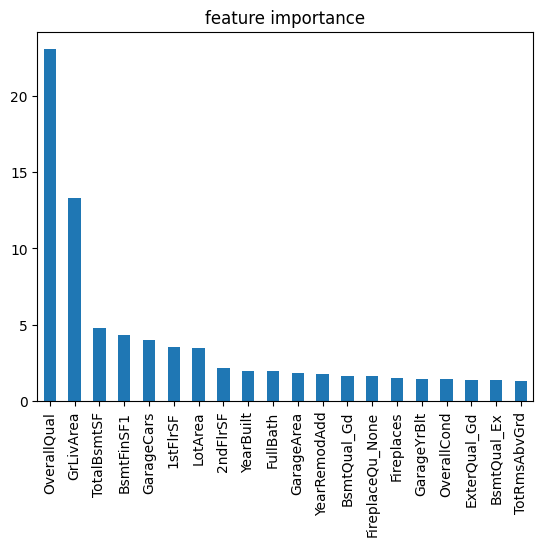

In [35]:
top_idx = cbr.feature_importances_.argsort()[-20:][::-1]

feature_dict = dict(zip(
    data.columns[top_idx],
    cbr.feature_importances_[top_idx]
))

feature_X = pd.DataFrame(feature_dict, index=[0])
feature_X.T.plot.bar(title='feature importance', legend=False)

## GradientBoostingRegressor

<Axes: title={'center': 'feature importance'}>

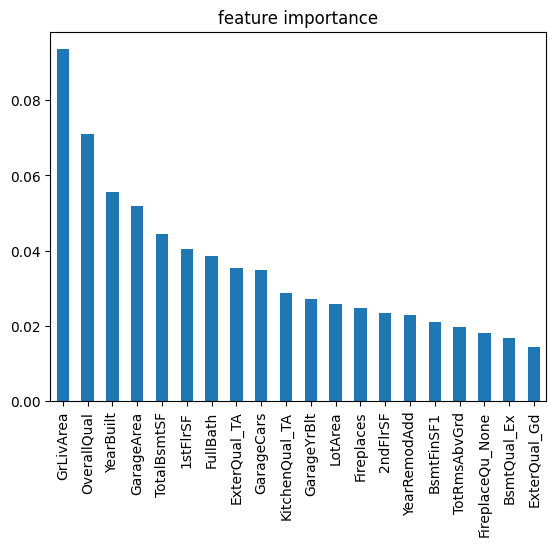

In [52]:
top_idx = gbr.best_estimator_.feature_importances_.argsort()[-20:][::-1]

feature_dict = dict(zip(
    data.columns[top_idx],
    gbr.best_estimator_.feature_importances_[top_idx]
))

feature_X = pd.DataFrame(feature_dict, index=[0])
feature_X.T.plot.bar(title='feature importance', legend=False)

# Generating predictions

To check the prediction on real-life data we can use this house: https://www.zillow.com/homedetails/2650-Somerset-Dr-Ames-IA-50010/93954822_zpid/

In [56]:
import numpy as np
print("your data:\n")
estimator = str(input('Choose estimator CatBoostRegressor(cbr)/GradientBoostingRegressor(gbr): '))

# input data (top 5 model features)
GrLivArea = float(input("Above grade (ground) living area square feet: "))
OverallQual = float(input("Overall quality: "))
TotalBsmtSF = float(input("Total square feet of basement area: "))
GarageArea = float(input("Size of garage in square feet: "))
YearBuilt = float(input("Original construction date: "))

new_data = {
    "GrLivArea": GrLivArea,
    "OverallQual": OverallQual,
    "YearBuilt": YearBuilt,
    "GarageArea": GarageArea,
    "TotalBsmtSF": TotalBsmtSF
}

new_data = pd.DataFrame([new_data])
new_data = pd.get_dummies(new_data)

numeric_cols = data.select_dtypes(include=np.number).columns # numeric columns
categorical_cols = [c for c in data.columns if c not in numeric_cols] # dummies columns

new_data = new_data.reindex(columns=data.columns) # reindexing
new_data[numeric_cols] = new_data[numeric_cols].fillna(X_train[numeric_cols].median()) # replacing missing values for numeric columns with median value
new_data[categorical_cols] = new_data[categorical_cols].fillna(0) # replacing missing values for dummies columns with 0

if estimator == 'cbr':
  prediction = cbr.predict(new_data)

elif estimator == 'gbr':
  prediction = np.expm1(gbr.predict(new_data))

else:
  print('error')


print('prediction for 2006-2010: ', prediction)

your data:

Choose estimator CatBoostRegressor(cbr)/GradientBoostingRegressor(gbr): cbr
Above grade (ground) living area square feet: 1812
Overall quality: 7
Total square feet of basement area: 900
Size of garage in square feet: 500
Original construction date: 2002
prediction for 2006-2010:  [165574.13497363]


From this table (https://www.fhfa.gov/document/d/hpi/fhfa-hpi-monthly-april-2026) we can see that the average price index in USA in 2008 was 213.34, but in 2026 it became 441.43. So, the average price of houses in USA increased by 106% from 2008 to 2026.

In [ ]:
data['YrSold'].median() # most common year of sale in dataset

2008.0

In [57]:
prediction_new = prediction * 1.06 + prediction
print(f'prediction for 2026: {prediction_new}')


prediction for 2026: [341082.71804567]


In [58]:
# for GradientBoostingRegressor
print(f'error score: {(374900 - 364091)/374900 *100}%') # 374900 - original price, 364091 - prediction
# for CatBoostRegressor
print(f'error score: {(374900 - 341082)/374900 *100}%') # 374900 - original price, 341082 - prediction


error score: 2.8831688450253403%
error score: 9.020538810349427%


# Saving models

In [60]:
import joblib
estimator = str(input('Choose estimator CatBoostRegressor(cbr)/GradientBoostingRegressor(gbr): '))

if estimator == 'cbr':
  model = cbr
  filename = 'cbr.pkl'

elif estimator == 'gbr':
  model = gbr
  filename = 'gbr.pkl'

else:
  print('error')

joblib.dump(model, filename)

Choose estimator CatBoostRegressor(cbr)/GradientBoostingRegressor(gbr): gbr


['gbr.pkl']

# Submission to Kaggle
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview

In [33]:
submission = pd.read_csv('sample_submission.csv')

estimator = str(input('Choose estimator CatBoostRegressor(cbr)/GradientBoostingRegressor(gbr): '))

if estimator == 'cbr':
  submission['SalePrice'] = y_pred_cbr

elif estimator == 'gbr':
  submission['SalePrice'] = y_pred_gbr

else:
  print('error')

submission.to_csv('my_submission.csv', index=False)

## Result using CatBoostRegressor:


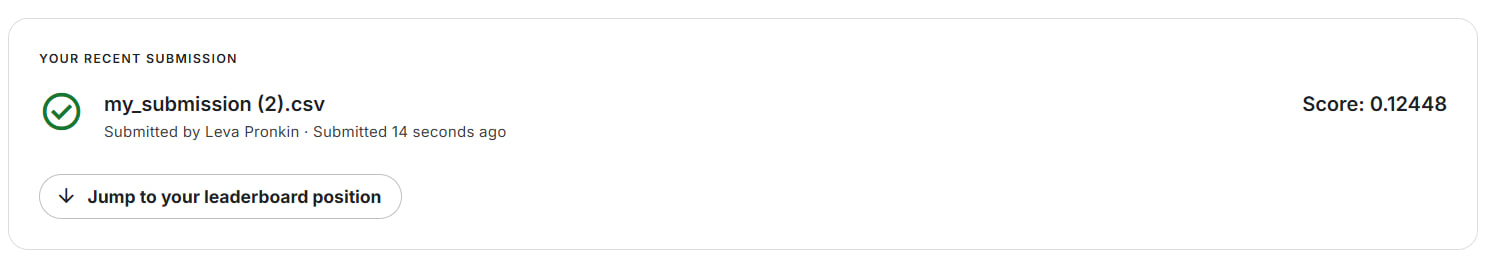